In [3]:
# Import libraries
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt


In [9]:
# load data 
df = pd.read_csv('/home/susan/MOF_project/data/raw/hmof_full_structural_co2.csv')
data = df.copy()
print(data .info())
print()
print('='*30)
print(data.shape)
print()
print('='*30)
print(data.columns)
print()
print('='*30)
data.head(5)



<class 'pandas.DataFrame'>
RangeIndex: 32768 entries, 0 to 32767
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   filename                  32768 non-null  str    
 1   lcd                       32768 non-null  float64
 2   pld                       32768 non-null  float64
 3   void_fraction             32768 non-null  float64
 4   surface_area_m2g          32768 non-null  float64
 5   mofid                     29063 non-null  str    
 6   CO2_uptake_0.01bar_molkg  32768 non-null  float64
 7   CO2_uptake_0.05bar_molkg  32768 non-null  float64
 8   CO2_uptake_0.1bar_molkg   32768 non-null  float64
 9   CO2_uptake_0.5bar_molkg   32768 non-null  float64
 10  CO2_uptake_2.5bar_molkg   32768 non-null  float64
dtypes: float64(9), str(2)
memory usage: 2.8 MB
None

(32768, 11)

Index(['filename', 'lcd', 'pld', 'void_fraction', 'surface_area_m2g', 'mofid',
       'CO2_uptake_0.01bar_molkg', 'CO2_u

,filename,lcd,pld,void_fraction,surface_area_m2g,mofid,CO2_uptake_0.01bar_molkg,CO2_uptake_0.05bar_molkg,CO2_uptake_0.1bar_molkg,CO2_uptake_0.5bar_molkg,CO2_uptake_2.5bar_molkg
0,hMOF-0,11.75,10.75,0.795539,3676.3,[O-]C(=O)c1ccc(cc1)C(=O)[O-].[Zn][O]([Zn])([Zn...,0.022406,0.073552,0.225851,0.885221,4.33307
1,hMOF-1,4.75,3.25,0.388986,580.7,[O-]C(=O)c1ccc(cc1)C(=O)[O-].[Zn][O]([Zn])([Zn...,0.173407,0.925813,1.806490,4.779010,7.34618
2,hMOF-10,4.75,3.75,0.307505,377.6,[O-]C(=O)c1cc(F)c(c(c1F)F)C(=O)[O-].[Zn][O]([Z...,0.651164,2.129830,2.817220,3.909470,4.93236
3,hMOF-100,9.25,8.25,0.731919,3399.2,COc1cc(cc(c1C(=O)[O-])OC)C(=O)[O-].COc1cc(ccc1...,0.031321,0.143123,0.332034,1.756380,6.91190
4,hMOF-1000,3.75,2.75,0.323803,85.2,CCc1cc(C(=O)[O-])c(c(c1C(=O)[O-])CC)CC.[O-]C(=...,0.144024,0.698367,1.402230,2.694200,4.15694


In [42]:
# column correction 
data.columns = (
    data.columns
    .str.strip()
    .str.replace(' ', '_', regex=False)
    .str.lower()
    .str.replace('co2', 'CO2', regex=False)
)
print(data.columns)
print()
print('='*30)
# check for missing and duplicated data 
missing_data = data.isna().sum()
missing_data = missing_data[missing_data > 0]

print('Missing values by column:')
print(missing_data)
print()
print('='*30)
# After missing value, inspect which rows are missing in the mofid column
print(data[data['mofid'].isna()].head())
print()
print('='*30)
# Check for duplicated data 
duplicate_data = data.duplicated().sum()
print(f'number of duplicated : {duplicate_data}')
print()
print('='*30)
# Investigate rows with surface_area_m2g = 0 (seen in test batch, e.g. hMOF-10002)
zero_surface_area = data[data['surface_area_m2g'] == 0]
print(zero_surface_area[['filename', 'mofid']])
print()
print('='*30)

# Drop rows where surface area is zero and mofid is missing
filtered_data = data.drop(
    data[(data['surface_area_m2g'] == 0) & (data['mofid'].isna())].index
)
print(filtered_data.shape)
print()
print('='*30)

missing_filtered_data = filtered_data.isna().sum()
missing_filtered_data = missing_filtered_data[missing_filtered_data > 0]

print('Missing values by column:')
print(missing_filtered_data)
print()
print('='*30)


clean_data = filtered_data.copy()

Index(['filename', 'lcd', 'pld', 'void_fraction', 'surface_area_m2g', 'mofid',
       'CO2_uptake_0.01bar_molkg', 'CO2_uptake_0.05bar_molkg',
       'CO2_uptake_0.1bar_molkg', 'CO2_uptake_0.5bar_molkg',
       'CO2_uptake_2.5bar_molkg'],
      dtype='str')

Missing values by column:
mofid    3705
dtype: int64

      filename    lcd    pld  void_fraction  surface_area_m2g mofid  \
10  hMOF-10005   8.75   7.75       0.733001            2954.6   NaN   
11  hMOF-10006  10.75   9.25       0.733034            2468.9   NaN   
12  hMOF-10007  12.25  11.25       0.821194            4204.3   NaN   
13  hMOF-10008   6.25   2.75       0.530844            1101.4   NaN   
14  hMOF-10009   4.25   3.75       0.309850             252.2   NaN   

    CO2_uptake_0.01bar_molkg  CO2_uptake_0.05bar_molkg  \
10                  0.091681                  0.266074   
11                  0.053527                  0.271804   
12                  0.032862                  0.111283   
13                  0.219827 

In [48]:
# Check for outliers in lcd, pld, void_fraction, surface_area_m2g
# Select numeric columns
numeric_cols = ['lcd', 'pld', 'void_fraction', 'surface_area_m2g']

# Show basic stats
print(clean_data[numeric_cols].describe())


                lcd           pld  void_fraction  surface_area_m2g
count  32591.000000  32591.000000   3.259100e+04      32591.000000
mean       8.544721      7.066706   6.202279e-01       2452.518005
std        3.780066      3.876933   2.097283e-01       1552.845055
min        0.000000      0.000000   1.039760e-42          0.000000
25%        5.750000      4.250000   5.207220e-01       1172.800000
50%        7.750000      5.750000   6.729270e-01       2436.400000
75%       10.750000      9.250000   7.759200e-01       3652.300000
max       24.250000     21.750000   9.276930e-01       6741.700000


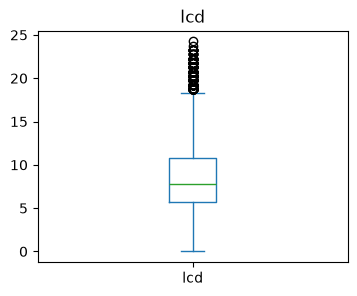

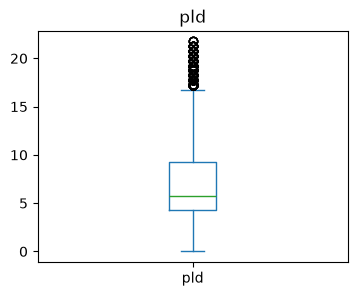

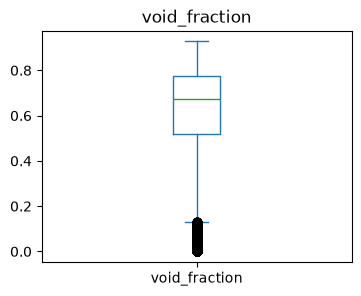

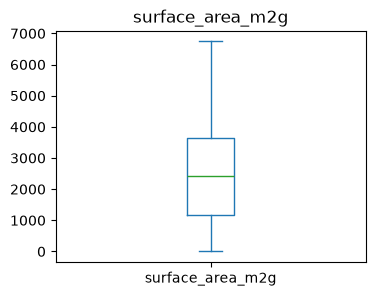

In [45]:
#  A simple way is to check numeric columns with summary statistics and boxplots.
# check for outliers with a boxplot:
for col in numeric_cols:
    plt.figure(figsize=(4, 3))
    data[col].plot(kind='box')
    plt.title(col)
    plt.show()


In [ ]:
# Detect outliers using the IQR rule:(standard method)
for col in numeric_cols:
    q1 = clean_data[col].quantile(0.25)
    q3 = clean_data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    outliers = clean_data[(clean_data[col] < lower) | (clean_data[col] > upper)]
    print(col, 'outliers:', len(outliers))
    print(outliers[[col, 'mofid']].head())

lcd outliers: 356
        lcd                                              mofid
382   19.25  [O-]C(=O)c1ccc(c2c1cccc2)C(=O)[O-].[O-]C(=O)c1...
451   20.25  N#Cc1c(ccc(c1C#N)c1c(C#N)cc(c(c1C#N)C#N)C(=O)[...
776   20.25  Fc1cc(C(=O)[O-])c(cc1C#Cc1cc(F)c(c(c1F)F)C(=O)...
1718  18.75  [O-]C(=O)c1c2ccccc2c(c2c1cccc2)C(=O)[O-].[O-]C...
1725  23.25  Fc1c(ccc(c1F)c1cc(F)c(c(c1F)F)C(=O)[O-])c1ccc(...
pld outliers: 387
        pld                                              mofid
382   17.75  [O-]C(=O)c1ccc(c2c1cccc2)C(=O)[O-].[O-]C(=O)c1...
393   17.25  Fc1cc(ccc1c1ccc(c(c1)F)C(=O)[O-])c1cc(F)c(c(c1...
451   19.25  N#Cc1c(ccc(c1C#N)c1c(C#N)cc(c(c1C#N)C#N)C(=O)[...
776   19.25  Fc1cc(C(=O)[O-])c(cc1C#Cc1cc(F)c(c(c1F)F)C(=O)...
1718  17.75  [O-]C(=O)c1c2ccccc2c(c2c1cccc2)C(=O)[O-].[O-]C...
void_fraction outliers: 1548
     void_fraction                                              mofid
7         0.135421  [O-]C(=O)C(=O)[O-].[O-]C(=O)c1ccc2c(c1)ccc(c2C...
38        0.090123  [O-]C(=O)C(=O)[O-].

## Data Cleaning Summary

- Loaded the dataset and inspected its structure, including shape, columns, and sample records.
- Standardized column names by removing extra whitespace, converting them to lowercase, and replacing spaces with underscores.
- Identified and summarized missing values by column.
- Reviewed rows with missing mofid values to assess data quality.
- Checked for duplicate records and counted them.
- Investigated rows with zero surface area and removed those with both zero surface area and missing mofid.
- Rechecked the remaining missing values after filtering.
- Explored potential outliers using descriptive statistics, boxplots, and the IQR method for key numeric features.

### Next Step
- The remaining missing values should be handled carefully, for example by imputation, removal, or using a model that can handle them.
